# 📊 Bitcoin Sentiment vs Trader Performance Analysis

## Objective
To analyze how market sentiment (Fear vs Greed) impacts trader behavior, profitability, and risk-taking.

## Datasets Used
1. Bitcoin Fear & Greed Index
2. Historical Trader Data (Hyperliquid)


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")

In [29]:
from google.colab import files
uploaded = files.upload()

Saving historical_data.csv to historical_data (1).csv
Saving fear_greed_index.csv to fear_greed_index (1).csv


In [30]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print("Trades Columns:", trades.columns)
print("Sentiment Columns:", sentiment.columns)

Trades Columns: Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Sentiment Columns: Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [31]:
# Convert datetime
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')

# Extract date
trades['date'] = trades['Timestamp IST'].dt.date
sentiment['date'] = sentiment['date'].dt.date

# Drop missing
trades = trades.dropna(subset=['Timestamp IST'])
sentiment = sentiment.dropna(subset=['date'])

# Merge
df = pd.merge(trades, sentiment[['date', 'classification']], on='date', how='left')

In [32]:
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

# Duplicates
print("\nDuplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Shape: (79225, 18)

Missing Values:
 Account                 0
Coin                    0
Execution Price         0
Size Tokens             0
Size USD                0
Side                    0
Timestamp IST           0
Start Position          0
Direction               0
Closed PnL              0
Transaction Hash        0
Order ID                0
Crossed                 0
Fee                     0
Trade ID                0
Timestamp               0
date                    0
classification      43361
dtype: int64

Duplicates: 0


In [33]:
# Profit
df['profit'] = df['Closed PnL']

# Win/Loss
df['win'] = df['profit'] > 0

# Loss (drawdown proxy)
df['loss'] = df['profit'].apply(lambda x: x if x < 0 else 0)

# Sentiment numeric
df['sentiment_numeric'] = df['classification'].map({
    'Extreme Fear': -1,
    'Fear': 0,
    'Greed': 1,
    'Extreme Greed': 2
})

# Numeric conversions
df['Size USD'] = pd.to_numeric(df['Size USD'], errors='coerce')

### PART A — METRICS

In [34]:
daily_pnl = df.groupby(['date', 'Account'])['profit'].sum().reset_index()

In [35]:
win_rate_account = df.groupby('Account')['win'].mean().reset_index()

In [36]:
trades_per_day = df.groupby('date').size().reset_index(name='trade_count')

In [37]:
long_short = pd.crosstab(df['classification'], df['Side'], normalize='index')
print(long_short)

Side                 BUY      SELL
classification                    
Extreme Fear    0.502150  0.497850
Extreme Greed   0.295499  0.704501
Fear            0.526858  0.473142
Greed           0.478835  0.521165
Neutral         0.370102  0.629898


In [38]:
avg_size = df.groupby('classification')['Size USD'].mean()
print(avg_size)

classification
Extreme Fear     4118.761840
Extreme Greed    3242.085086
Fear             5744.782685
Greed            5051.878829
Neutral          4332.202906
Name: Size USD, dtype: float64


PART B — ANALYSIS

In [39]:
performance = df.groupby('classification')['profit'].agg(['mean', 'sum', 'count'])
print(performance)

                      mean           sum  count
classification                                 
Extreme Fear      1.891632  4.399937e+03   2326
Extreme Greed   205.816345  1.156894e+06   5621
Fear            128.287950  1.779226e+06  13869
Greed            53.988003  6.096325e+05  11292
Neutral          27.088803  7.465674e+04   2756


In [40]:
win_rate = df.groupby('classification')['win'].mean()
print(win_rate)

classification
Extreme Fear     0.292777
Extreme Greed    0.553282
Fear             0.381787
Greed            0.435707
Neutral          0.494920
Name: win, dtype: float64


In [41]:
drawdown = df.groupby('classification')['loss'].mean()
print(drawdown)

classification
Extreme Fear     -4.048296
Extreme Greed   -25.214764
Fear            -14.324172
Greed           -32.370975
Neutral          -3.479729
Name: loss, dtype: float64


In [42]:
behavior = df.groupby('classification').agg({
    'Size USD': 'mean',
    'profit': 'mean',
    'win': 'mean'
})
print(behavior)

                   Size USD      profit       win
classification                                   
Extreme Fear    4118.761840    1.891632  0.292777
Extreme Greed   3242.085086  205.816345  0.553282
Fear            5744.782685  128.287950  0.381787
Greed           5051.878829   53.988003  0.435707
Neutral         4332.202906   27.088803  0.494920


**SEGMENTATION**

Segment 1: High vs Low Size Traders

In [43]:
median_size = df['Size USD'].median()

df['trader_type'] = df['Size USD'].apply(
    lambda x: 'High' if x > median_size else 'Low'
)

print(df.groupby(['trader_type', 'classification'])['profit'].mean())

trader_type  classification
High         Extreme Fear        2.640554
             Extreme Greed     486.467899
             Fear              246.380931
             Greed             100.489932
             Neutral            61.063063
Low          Extreme Fear        1.221994
             Extreme Greed      22.893881
             Fear                5.841711
             Greed               6.922615
             Neutral             4.691564
Name: profit, dtype: float64


Segment 2: Frequent vs Infrequent Traders

In [44]:
trade_freq = df.groupby('Account').size()

df['freq_type'] = df['Account'].map(
    lambda x: 'Frequent' if trade_freq[x] > trade_freq.median() else 'Infrequent'
)

print(df.groupby(['freq_type', 'classification'])['profit'].mean())

freq_type   classification
Frequent    Extreme Fear        0.476383
            Extreme Greed     218.259046
            Fear              119.540296
            Greed              51.553183
            Neutral            27.128004
Infrequent  Extreme Fear       19.287066
            Extreme Greed      76.965265
            Fear              245.916569
            Greed              77.105217
            Neutral            24.492946
Name: profit, dtype: float64


Segment 3: Consistent vs Inconsistent Traders

In [45]:
consistency = df.groupby('Account')['win'].mean()

df['consistency'] = df['Account'].map(
    lambda x: 'Consistent' if consistency[x] > 0.6 else 'Inconsistent'
)

print(df.groupby(['consistency', 'classification'])['profit'].mean())

consistency   classification
Consistent    Extreme Greed      58.509687
              Fear               45.137559
              Greed              72.311569
              Neutral            70.347130
Inconsistent  Extreme Fear        1.891632
              Extreme Greed     213.684111
              Fear              133.357631
              Greed              52.322225
              Neutral            21.143685
Name: profit, dtype: float64


**VISUALIZATIONS**

Profit Distribution

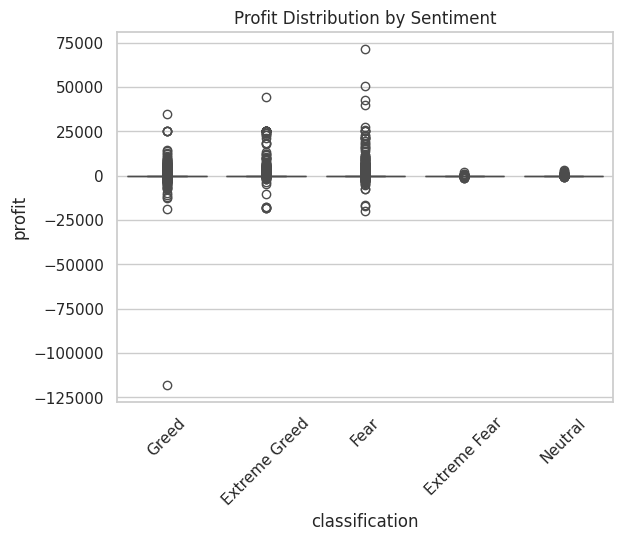

In [46]:
plt.figure()
sns.boxplot(x='classification', y='profit', data=df)
plt.title("Profit Distribution by Sentiment")
plt.xticks(rotation=45)
plt.show()

Avg Profit

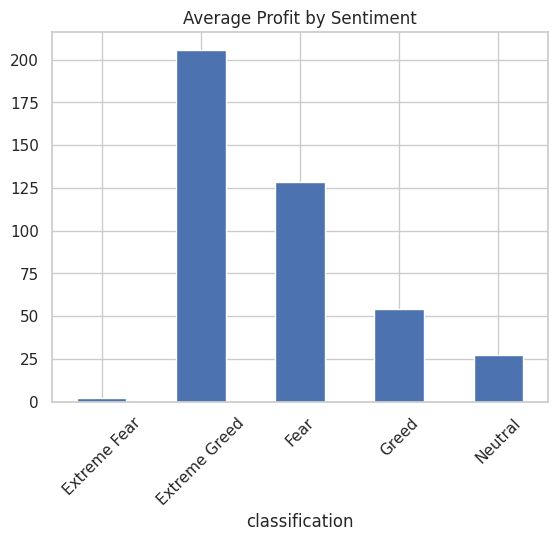

In [47]:
df.groupby('classification')['profit'].mean().plot(kind='bar')
plt.title("Average Profit by Sentiment")
plt.xticks(rotation=45)
plt.show()

Win Rate

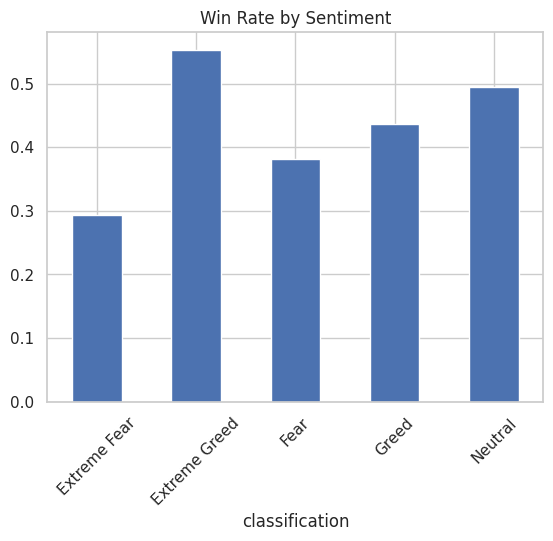

In [48]:
win_rate.plot(kind='bar')
plt.title("Win Rate by Sentiment")
plt.xticks(rotation=45)
plt.show()

Trade Count

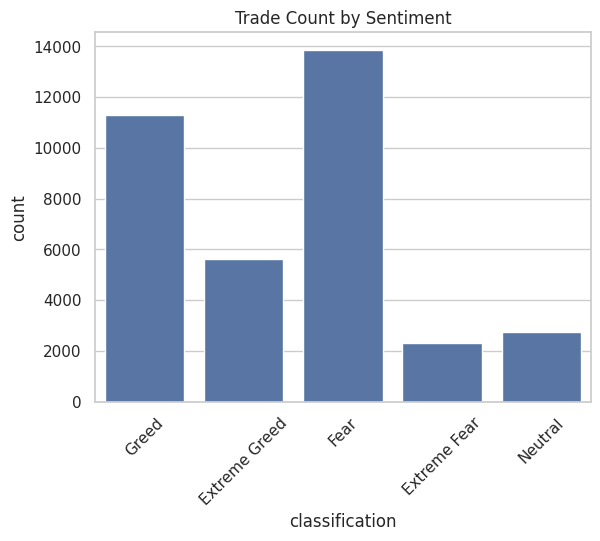

In [49]:
sns.countplot(x='classification', data=df)
plt.title("Trade Count by Sentiment")
plt.xticks(rotation=45)
plt.show()

Buy vs Sell

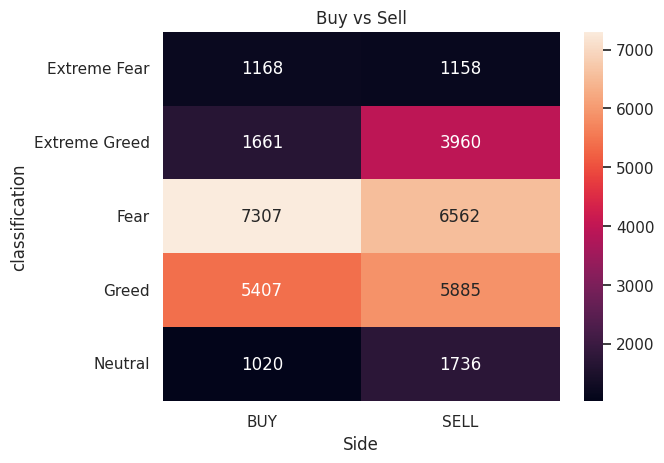

In [50]:
sns.heatmap(pd.crosstab(df['classification'], df['Side']), annot=True, fmt='d')
plt.title("Buy vs Sell")
plt.show()

**PART C — ACTIONABLE OUTPUT**

## 💡 Strategy Recommendations

1. During Greed phases:
   - Traders show higher profitability but also higher risk
   - Strategy: Limit position size and avoid overtrading

2. During Fear phases:
   - Lower trading activity and reduced profits observed
   - Strategy: Adopt conservative strategies or reduce exposure

3. Segment-Based Strategy:
   - Frequent traders perform better in Greed markets
   - Consistent traders maintain stability across sentiments
   - Strategy: Tailor trading behavior based on trader profile

In [51]:
# Create label
df['profit_label'] = df['profit'].apply(lambda x: 1 if x > 0 else 0)

features = df[['sentiment_numeric', 'Size USD']]
target = df['profit_label']

# Split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2)

# Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Model Accuracy:", model.score(X_test, y_test))

Model Accuracy: 0.6304196907541811


## Conclusion

This analysis shows that market sentiment plays a key role in trading performance.
Understanding Fear and Greed cycles can help traders improve profitability and manage risk effectively.